<a href="https://colab.research.google.com/github/lpodina/conformal_pinns/blob/main/Test_Conformal_PINNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import warnings
from scipy.integrate import odeint
from matplotlib import style
import numpy as np

warnings.filterwarnings('ignore')

np.random.seed(1234)

# CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Device is {device}")
"""## Physics-informed Neural Networks"""

# define the right-hand side
def logistic_growth(N, t, r, K):
    return r * N * (1 - N/K)

Device is cuda


Step 1. Generate Data
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


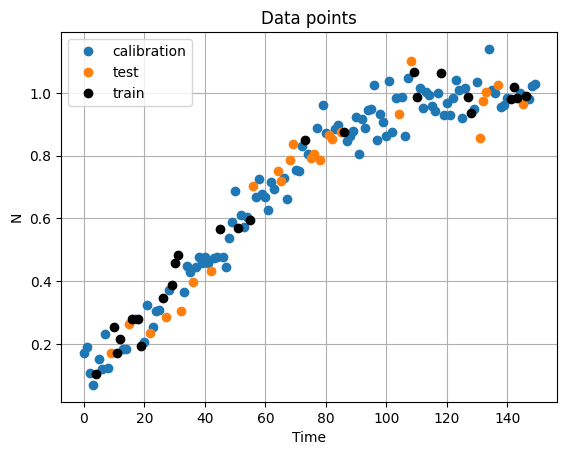

<Figure size 640x480 with 0 Axes>

In [ ]:
# # Step 1. Generate Data
print("Step 1. Generate Data")

max_t = 150
step_size = 1.0
#step_size = 0.1 # MTR
noise = 0.08 # 0.0 or 0.03 <- change this to 0.03 to see how noise will affect performance

t = np.arange(0, max_t, step_size) #0.1
p_ = (0.05, 1.0)

ic = 0.1
# X is ideal noiseless data
X = odeint(logistic_growth, ic, t, args=p_)

# Add noise according to the mean
xbar = np.mean(X, axis=0)
Xn = X + noise * xbar * np.random.randn(*X.shape)

t_cal, t_traintest, N_cal, N_traintest = train_test_split(t, Xn, test_size=0.33, random_state=42)
t_train, t_test, N_train, N_test = train_test_split(t_traintest, N_traintest, test_size=0.50, random_state=42)

print(f"num calibration: {t_cal.shape},{N_cal.shape}")
print(f"num train: {t_train.shape},{N_train.shape}")
print(f"num test: {t_test.shape},{N_test.shape}")

t_train = np.expand_dims(t_train.copy(),axis=1)
t_test = np.expand_dims(t_test.copy(),axis=1)
t_cal = np.expand_dims(t_cal.copy(),axis=1)

t_colloc = np.expand_dims(np.arange(0, max_t, 0.001),axis=1)

# plot the data for sanity check
plt.grid()
plt.title("Data points")
plt.xlabel("Time")
plt.ylabel("N")
plt.plot(t_cal, N_cal,'o',label='calibration')
plt.plot(t_test, N_test,'o',label='test')
plt.plot(t_train, N_train,'o',color='k',label='train')
plt.legend()
plt.savefig('data')
plt.show()
plt.clf()

In [ ]:

# the deep neural network
class DNN(torch.nn.Module):
    def __init__(self, layers, min_val, max_val):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        self.min_val = torch.tensor([min_val], requires_grad=True).float().to(device)
        self.max_val = torch.tensor([max_val], requires_grad=True).float().to(device)

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        res = (x - self.min_val) / (self.max_val - self.min_val)
        out = self.layers(res)
        return out

max_lr = -1
min_lr = -3

time_delta = 30000
warm_ups = 1000
rate = (min_lr - max_lr) / time_delta

def lr_schedule(epoch):
    """Linear annealing LR schedule."""
    if epoch < warm_ups:
        return 10**(max_lr)
    elif epoch < time_delta:
        return 10**(rate * (epoch - warm_ups) + max_lr)
    else:
        return 10**min_lr

# the physics-guided neural network
class PhysicsInformedNN():
    def __init__(self, t_colloc, layers, t_train, u_data):

        # save the training data
        self.t_train = torch.tensor(t_train, requires_grad=True).float().to(device) # t
        self.u_data = torch.tensor(u_data, requires_grad=True).float().to(device) # N

        # save the collocation times as well
        self.t_colloc = torch.tensor(t_colloc, requires_grad=True).float().to(device)

        # You need to know the parameters of the differential equation
        self.r = torch.tensor([0.05], requires_grad=True).float().to(device) # parameters
        self.K = torch.tensor([1.0], requires_grad=True).float().to(device)

        # deep neural networks
        print(f"layers: {layers}")

        self.dnn = DNN(layers,0.0,150.0).to(device)

        # optional 4 lines: if you want to fit the parameters as well
        # self.r = torch.nn.Parameter(self.r)
        # self.K = torch.nn.Parameter(self.K)
        # self.dnn.register_parameter('r', self.r)
        # self.dnn.register_parameter('K', self.K)

         # optimizers: using the same settings
        self.optimizer = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=1.0,
            max_iter=50000,
            max_eval=50000,
            history_size=50,
            tolerance_grad=0,#1e-8,
            tolerance_change=0,#1.0 * np.finfo(float).eps,
            line_search_fn="strong_wolfe"       # can be "strong_wolfe"
        )

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters())
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(self.optimizer_Adam, lr_lambda=lr_schedule)
        self.iter = 0

    def net_u(self, t):
        u = self.dnn(t)
        return u

    def net_f(self, t_colloc):
        """ The pytorch autograd version of calculating residual """
        u_colloc = self.net_u(t_colloc)

        _u = torch.unsqueeze(u_colloc[:, 0],axis=1)

        u_t = torch.autograd.grad(
            _u, t_colloc,
            grad_outputs=torch.ones_like(_u),
            retain_graph=True,
            create_graph=True,
        )[0]

        u_dot = self.r * _u * (1 - _u/self.K)
        loss_pinn = torch.mean(torch.square(u_t - u_dot))

        return loss_pinn

    # this loss func is for the LBFGS optimizer
    def loss_func(self):
        self.optimizer.zero_grad()

        # compute the loss
        u_pred = self.net_u(self.t_train)
        data_loss = torch.mean((self.u_data - u_pred) ** 2) # mse loss
        pinn_loss = self.net_f(self.t_colloc) # pinn loss

        loss = data_loss + pinn_loss # add them together to get final loss

        loss.backward()

        self.iter += 1
        if self.iter % 100 == 0:
            print(
                'Loss: %.3e, pinn loss: %.3e, data loss: %.3e, r: %.3f, K: %.6f' %
                (
                    loss.item(),
                    pinn_loss.item(),
                    data_loss.item(),
                    self.r.item(),
                    self.K.item()
                )
            )
        return loss

    def train(self, adam_epochs, bfgs_epochs, polish_adam_epochs):
        self.dnn.train()

        for epoch in range(adam_epochs):
            u_pred = self.net_u(self.t_train)
            data_loss = torch.mean((self.u_data - u_pred) ** 2)
            pinn_loss = self.net_f(self.t_colloc)

            loss = data_loss + pinn_loss

            # Backward and optimize
            self.optimizer_Adam.zero_grad()
            loss.backward()
            self.optimizer_Adam.step()
            self.scheduler.step()

            if epoch % 100 == 0:
                print(
                    'It: %d, Loss: %.3e, pinn loss: %.3e, data loss: %.3e, r: %.3f, K: %.6f' %
                    (
                        epoch,
                        loss.item(),
                        pinn_loss.item(),
                        data_loss.item(),
                        self.r.item(),
                        self.K.item()
                    )
                )
        self.optimizer.step(self.loss_func)

    def predict(self, t):
        t = torch.tensor(t, requires_grad=True).float().to(device)

        self.dnn.eval()
        u = self.net_u(t)
        u = u.detach().cpu().numpy()
        return u

In [ ]:
# Step 2. Setup Training
print("Step 2. Set Up Training")

"""## Configurations"""

layers = [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]

"""## Training on Non-noisy Data"""

adam_epochs = 1000
polish_adam_epochs = 2000
bfgs_epochs = 2000

# training
model = PhysicsInformedNN(t_colloc, layers, t_train, N_train)
model.train(adam_epochs, bfgs_epochs, polish_adam_epochs)

Step 2. Set Up Training
layers: [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
It: 0, Loss: 9.142e-01, pinn loss: 2.946e-04, data loss: 9.139e-01, r: 0.050, K: 1.000000
It: 100, Loss: 4.796e-01, pinn loss: 7.182e-07, data loss: 4.796e-01, r: 0.050, K: 1.000000
It: 200, Loss: 1.270e-01, pinn loss: 1.530e-04, data loss: 1.269e-01, r: 0.050, K: 1.000000
It: 300, Loss: 1.030e-01, pinn loss: 1.317e-04, data loss: 1.028e-01, r: 0.050, K: 1.000000
It: 400, Loss: 9.117e-02, pinn loss: 1.218e-04, data loss: 9.105e-02, r: 0.050, K: 1.000000
It: 500, Loss: 5.469e-02, pinn loss: 8.711e-05, data loss: 5.460e-02, r: 0.050, K: 1.000000
It: 600, Loss: 4.757e-03, pinn loss: 8.491e-06, data loss: 4.748e-03, r: 0.050, K: 1.000000
It: 700, Loss: 2.623e-03, pinn loss: 7.117e-06, data loss: 2.616e-03, r: 0.050, K: 1.000000
It: 800, Loss: 2.609e-03, pinn loss: 7.190e-06, data loss: 2.601e-03, r: 0.050, K: 1.000000
It: 900, Loss: 2.597e-03, pinn loss: 7.197e-06, data loss: 2.589e-03, r: 0.050, K: 1.000000
Loss: 1.812

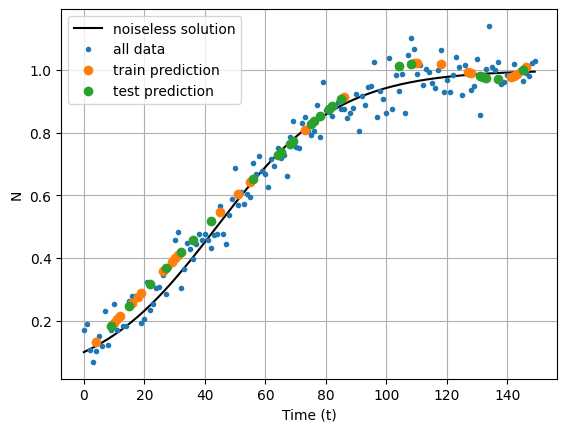

In [ ]:
# evaluations
u_pred= model.predict(model.t_colloc) # predict on collocation time-points
u_pred_test = model.predict(t_test) # predict on calibration points
u_pred_train = model.predict(t_train) # predict on calibration points
# print(u_pred)

# plt.title("Trajectories")
plt.xlabel('Time (t)')
plt.grid()
plt.ylabel("N")
plt.plot(t, X, '-',c='k',label='noiseless solution')
plt.plot(t, Xn, '.',label='all data')
plt.plot(t_train, u_pred_train, 'o',label='train prediction')
# plt.plot(t_cal,N_cal,'.',label='True calibration points')
# plt.plot(t_cal, u_pred_calibration, 'o',label='calibration prediction')
plt.plot(t_test, u_pred_test, 'o',label='test prediction')
# plt.plot(model.t_colloc.detach().cpu().numpy(), u_pred[:, 0],'-', label='PINN approximation', color='r')
plt.savefig('trajectories')
plt.legend()
plt.show()

In [ ]:
class Conformalizer():
  def __init__(self,
               pre_trained_model,
               non_conformity_func,
               delta,
               calib_data):

    # Initialize the conformalizer with required parameters
    self.point_predictor = pre_trained_model
    self.non_conformity_func = non_conformity_func
    self.n_calib = calib_data['X'].shape[0]
    self.delta = delta
    #self.X_calib, self.y_calib = calib_data['X'], calib_data['y']
    self._calibrate(calib_data['X'], calib_data['y'])


  def _calculate_quantile(self, scores_calib, delta):
    # Calculate the quantile value based on delta and non-conformity scores
    self.which_quantile = np.ceil((self.delta)*(self.n_calib + 1))/self.n_calib
    return np.quantile(scores_calib, self.which_quantile, method='lower')


  def _calibrate(self, X_calib, y_calib):
    # Calibrate the conformalizer to calculate q_hat
    y_calib_pred = self.point_predictor.predict(X_calib)
    scores_calib = self.non_conformity_func(y_calib_pred, y_calib)
    self.q_hat = self._calculate_quantile(scores_calib, self.delta)


  def predict(self, X):
    # Returns the predicted interval
    y_pred = self.point_predictor.predict(X)
    y_lower, y_upper = y_pred - self.q_hat, y_pred + self.q_hat
    return y_lower, y_pred, y_upper

In [ ]:
def non_conformity_func(y, y_hat):
  return np.abs(y - y_hat)

In [ ]:
t_cal.shape, N_cal.shape

((100, 1), (100, 1))

In [ ]:
fresh_points_for_conformalizer_X = t_cal
fresh_points_for_conformalizer_y = N_cal

In [ ]:
alpha = 0.1
sig_level_delta = 1 - alpha
calib_data, valid_data = {}, {}
n_calib = 80
n_valid = fresh_points_for_conformalizer_X.shape[0] - n_calib

lower_bound, upper_bound, exact_coverage = sig_level_delta, (sig_level_delta + 1/(n_calib+1)), (np.ceil((n_calib+1)*sig_level_delta))/(n_calib+1)
# To see how the relations for upper bound and the exact coverage are derived, see the following video:
# Uncertainty Quantification (4A): Implementing Split Conformal - Relation for Prediction Intervals


empirical_coverages_for_all_trials = []
num_trials = 10000

for trial_num in range(num_trials):
  calib_data['X'], valid_data['X'], calib_data['y'], valid_data['y'] = train_test_split(fresh_points_for_conformalizer_X, N_cal, test_size=n_valid)
  conformalized_model = Conformalizer(model, non_conformity_func, sig_level_delta, calib_data)
  y_lower, y_pred, y_upper = conformalized_model.predict(valid_data['X'])
  fraction_within_bounds = np.mean((valid_data['y']  >= y_lower) & (valid_data['y'] <= y_upper))
  empirical_coverage = fraction_within_bounds
  empirical_coverages_for_all_trials.append(empirical_coverage)


In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import (inset_axes, InsetPosition,
                                                  mark_inset)

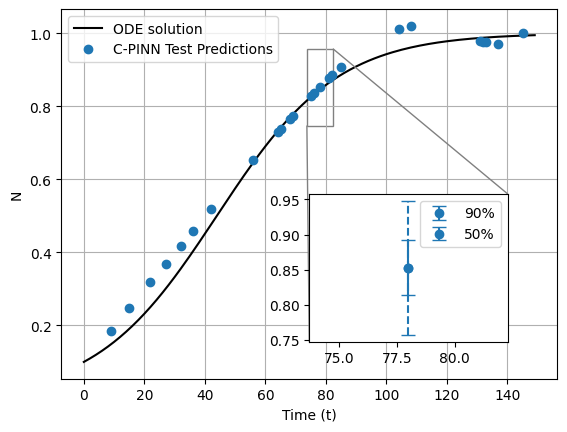

In [ ]:
calib_data['X'], valid_data['X'], calib_data['y'], valid_data['y'] = train_test_split(fresh_points_for_conformalizer_X, N_cal, test_size=n_valid)
conformalized_model = Conformalizer(model, non_conformity_func, 0.5, calib_data)
y_lower, y_pred, y_upper = conformalized_model.predict(valid_data['X'])

qhat_50 = (y_upper - y_pred)[0][0]

calib_data['X'], valid_data['X'], calib_data['y'], valid_data['y'] = train_test_split(fresh_points_for_conformalizer_X, N_cal, test_size=n_valid)
conformalized_model = Conformalizer(model, non_conformity_func, 0.90, calib_data)
y_lower, y_pred, y_upper = conformalized_model.predict(valid_data['X'])

qhat_90 = (y_upper - y_pred)[0][0]
# print(valid_data['X'].shape)
# print(valid_data['y'].shape)


fig, ax1 = plt.subplots()

# plt.title("Trajectories")
plt.xlabel('Time (t)')
plt.grid()
plt.ylabel("N")
plt.plot(t, X, '-',c='k',label='ODE solution')
# plt.plot(t, Xn, '.',c='k',label='ODE solution + noise')
# plt.plot(t_train, u_pred_train, 'o',label='train prediction')
# plt.plot(t_cal,N_cal,'.',label='True calibration points')
# plt.plot(t_cal, u_pred_calibration, 'o',label='calibration prediction')
plt.plot(t_test, u_pred_test, 'o',c='tab:blue',label='C-PINN Test Predictions')
# plt.errorbar(valid_data['X'].flatten(),y_pred.flatten(),yerr=qhat,fmt='.',label='validation predictions')
# plt.plot(valid_data['X'],valid_data['y'],'.',label='validation points')

lb = 76
ub = 79

test_t_small = t_test[(lb < t_test) & (t_test < ub)]
test_N_small = u_pred_test[(lb < t_test) & (t_test < ub)]

ax2 = ax1.inset_axes([0.5,0.1,0.4,0.4])#[0.0,0.0,1,1])
# Manually set the position and relative size of the inset axes within ax1
# ip = InsetPosition(ax1, [0.5,0.1,0.4,0.4])
# ax2.set_axes_locator(ip)
# Mark the region corresponding to the inset axes on ax1 and draw lines
# in grey linking the two axes.
eb_90 = ax2.errorbar(test_t_small, test_N_small, yerr=qhat_90,capsize=5,c='tab:blue',fmt='o',label='90%')
ax2.errorbar(test_t_small, test_N_small, yerr=qhat_50,capsize=5,c='tab:blue',fmt='o',label='50%')
eb_90[-1][0].set_linestyle('--')
# ax2.grid()
ax2.legend()
mark_inset(ax1, ax2, loc1=1, loc2=3, fc="none", ec='0.5')
plt.legend()
# plt.plot(model.t_colloc.detach().cpu().numpy(), u_pred[:, 0],'-', label='PINN approximation', color='r')
plt.savefig('trajectories')

plt.show()


# # plt.title("Trajectories")
# plt.xlabel('Time (t)')
# plt.grid()
# plt.ylabel("N")
# plt.plot(t, X, '-',label='noiseless solution')
# # plt.plot(t, Xn, '.',label='all data')
# # plt.plot(t_train, u_pred_train, 'o',label='train prediction')
# # plt.plot(calib_data['X'],calib_data['y'],'.',label='calibration points')
# plt.errorbar(valid_data['X'].flatten(),y_pred.flatten(),yerr=qhat,fmt='.',label='validation predictions')
# plt.plot(valid_data['X'],valid_data['y'],'.',label='validation points')
# # plt.plot(t_cal, u_pred_calibration, 'o',label='calibration prediction')
# # plt.plot(t_test, u_pred_test, 'o',label='test prediction')
# # plt.plot(model.t_colloc.detach().cpu().numpy(), u_pred[:, 0],'-', label='PINN approximation', color='r')
# plt.savefig('trajectories')
# plt.legend()
# plt.show()

In [ ]:
def running_average(arr):
  cumsum = np.cumsum(arr)
  indices = np.arange(1, len(arr) + 1)
  running_avg = cumsum / indices
  return running_avg

In [ ]:
running_averages = running_average(empirical_coverages_for_all_trials)

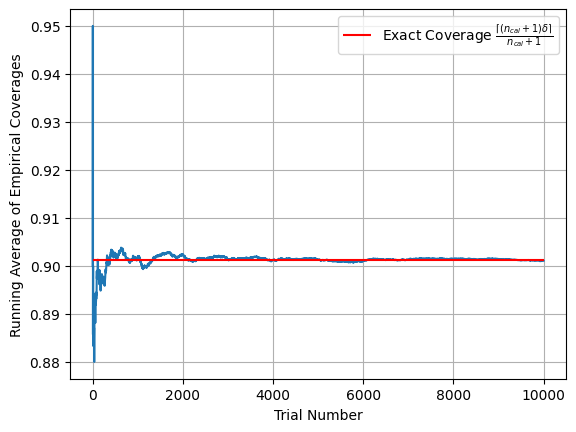

In [ ]:
plt.plot(running_averages)
plt.grid()
# plt.hlines(lower_bound, 0, num_trials, label=r'Lower Bound = 1 - $\alpha$')
# plt.hlines(upper_bound, 0, num_trials, label=r'Upper Bound = 1 - $\alpha$ + $\frac{1}{n_{cal}+1}$')
plt.hlines(exact_coverage, 0, num_trials, label=r'Exact Coverage $\frac{\lceil (n_{cal}+1)\delta \rceil}{n_{cal}+1}$', color='r')
# (np.ceil((n_calib+1)*sig_level_delta))/(n_calib+1)
# \frac{\lceil (n+1) \cdot \text{sig\_level} \rceil}{n+1}
plt.xlabel('Trial Number')
plt.ylabel('Running Average of Empirical Coverages')
plt.legend()
#plt.ylim(0.899, 0.903)

In [ ]:
# Just want to isolate that inside of the loop to know what the interval is
calib_data['X'], valid_data['X'], calib_data['y'], valid_data['y'] = train_test_split(fresh_points_for_conformalizer_X, N_cal, test_size=n_valid)
conformalized_model = Conformalizer(model, non_conformity_func, sig_level_delta, calib_data)
y_lower, y_pred, y_upper = conformalized_model.predict(valid_data['X'])
print((y_upper - y_lower)[0])

# the value is about 0.001 for noiseless data
# the value is about 0.076 for noise=0.03 data

[0.00057971]
